# 05 — สรุปปัญหาและข้อเสนอแนะ

รวมตัวเลขจาก notebook 01–04 (อ่านจาก `results/*.json` ไม่คำนวณใหม่) เป็นปัญหาหลัก 4 ข้อ
แต่ละข้อมี หลักฐานจากข้อมูล → ผลกระทบที่น่าจะเกิด → ข้อเสนอแนะ แล้ววาดกระบวนการ as-is (ย่อ) และ to-be

ข้อมูลเป็น **ข้อมูลจำลอง** ผลกระทบและสาเหตุเป็นข้อสันนิษฐาน ไม่มีการอ้างว่าลดต้นทุนหรือเพิ่มประสิทธิภาพได้เท่าไร

In [1]:
import json, sys
from pathlib import Path
import pandas as pd, graphviz
ROOT = Path.cwd().parent; FIG = ROOT/'figures'
E = json.loads((ROOT/'results'/'01_explore.json').read_text())
D = json.loads((ROOT/'results'/'02_discovery.json').read_text())
C = json.loads((ROOT/'results'/'03_conformance.json').read_text())
P = json.loads((ROOT/'results'/'04_performance.json').read_text())
rule = {r['rule'][:2]: r for r in C['rules']}
pay_n_max = next(r['max'] for r in E['repeats'] if r['object_type']=='payment' and r['activity']=='Execute Payment')
N = C['cases']; R = {}

## 1. ตารางปัญหาหลัก

In [2]:
issues = [
 {'id':'P1', 'issue':'เริ่มจัดซื้อโดยไม่มีใบขอซื้อในระบบ',
  'evidence': f"{rule['A1']['cases']} จาก {N} เคส ({rule['A1']['cases_pct']}%) เริ่มที่ 'Create Request for Quotation' และใบขอซื้อทั้ง {C['pr_release_indicator_by_group']['Released']['no PR created']} ใบยังมีสถานะ 'Released'",
  'impact':'ผูกพันค่าใช้จ่ายได้โดยไม่มีหลักฐานความต้องการหรือการอนุมัติงบ (maverick buying) และ audit trail ไม่ครบ',
  'recommendation':'บล็อกการสร้าง RFQ ที่ไม่อ้างใบขอซื้อที่อนุมัติแล้ว และรายงานรายการที่ไม่มีใบขอซื้อให้หัวหน้าจัดซื้อทุกสัปดาห์'},
 {'id':'P2', 'issue':'ส่งต่อการอนุมัติ แต่ไม่มีบันทึกการอนุมัติ',
  'evidence': f"{rule['A2']['cases']} เคส ({rule['A2']['cases_pct']}%) มี 'Delegate Purchase Requisition Approval' แต่ไม่มี event อนุมัติตามมา ทั้งที่ใบขอซื้อมีสถานะ 'Released'",
  'impact':'ไม่มีหลักฐานว่าใครเป็นผู้อนุมัติจริง แสดงการแบ่งแยกหน้าที่ (segregation of duties) ให้ผู้ตรวจสอบไม่ได้',
  'recommendation':'ให้การ delegate ส่งงานไปที่ผู้รับมอบ และต้องมี event อนุมัติของผู้รับมอบก่อนปลดล็อกใบขอซื้อ'},
 {'id':'P3', 'issue':'สั่งจ่ายเงินซ้ำกับใบแจ้งหนี้เดิม',
  'evidence': f"{C['D1_payments']} payment ({rule['D1']['cases_pct']}% ของเคส) ถูกสั่งจ่าย 2–{int(pay_n_max)} ครั้ง (เกินมา {C['D1_extra_executions']} ครั้ง) ทุกครั้งอ้างใบรับของชุดเดิม ห่างกันมัธยฐาน {C['D1_days_between_executions']['50%']} วัน ถ้าทุกครั้งเป็นยอดเต็ม เพดานบนคือ {C['D1_exposure_pct_of_invoiced']}% ของยอดใบแจ้งหนี้",
  'impact':'อาจจ่ายเงินซ้ำและเงินสดรั่วไหล การเงินต้องตามเรียกคืน ข้อมูลไม่มียอดเงินรายครั้ง จึงยังไม่ยืนยันความเสียหาย',
  'recommendation':f"เพิ่มการตรวจจ่ายซ้ำ (ใบแจ้งหนี้/ผู้ขาย/ยอดเงินเดียวกัน) ก่อนรันจ่ายเงิน และให้การเงินทบทวน {C['D1_payments']} payment ที่พบ"},
 {'id':'P4', 'issue':'จ่ายเงินให้ PO ก่อนรับของครบ',
  'evidence': f"{rule['C5']['documents']} PO ใน {rule['C5']['cases']} เคส ({rule['C5']['cases_pct']}%) มีการรับของ {C['C5_postings_after_payment']} ครั้งหลังจ่ายเงินแล้ว (มัธยฐาน {C['C5_days_after_payment']['50%']} วันหลังจ่าย) การจับคู่ที่บันทึกเป็น two-way ทั้งหมด ({C['two_way_match_events']} ครั้ง, three-way {C['three_way_match_events']} ครั้ง)",
  'impact':'เสี่ยงจ่ายเงินให้ของที่ส่งไม่ครบหรือไม่ได้ส่ง',
  'recommendation':'เปลี่ยนเป็น three-way match (PO–ใบรับของ–ใบแจ้งหนี้) และจ่ายเฉพาะจำนวนที่รับจริง'},
 {'id':'P5', 'issue':'เวลาส่วนใหญ่อยู่ในการส่งต่องานภายใน',
  'evidence': f"มัธยฐานทั้งเคส {P['case_duration_days']['median']} วัน ไม่มีขั้นใดเด่นเป็นคอขวดเดียว ขั้นที่องค์กรควบคุมเองได้ (อนุมัติ/ส่งต่อ/การเงิน) คิดเป็น {P['internal_share_of_stage_medians_pct']}% ของผลรวมค่ามัธยฐานรายขั้น",
  'impact':'รอบจัดซื้อถึงจ่ายเงินช้า เพราะคิวระหว่างทีม มากกว่าการรอผู้ขาย',
  'recommendation':'อนุมัติอัตโนมัติเมื่อมูลค่าต่ำ, สร้าง RFQ อัตโนมัติเมื่อใบขอซื้ออนุมัติ, รันจ่ายเงินถี่ขึ้นสำหรับใบแจ้งหนี้ที่จับคู่แล้ว'},
]
iss = pd.DataFrame(issues); R['issues'] = issues
pd.set_option('display.max_colwidth', 120); iss[['id','issue','evidence']]

,id,issue,evidence
0,P1,เริ่มจัดซื้อโดยไม่มีใบขอซื้อในระบบ,198 จาก 927 เคส (21.4%) เริ่มที่ 'Create Request for Quotation' และใบขอซื้อทั้ง 198 ใบยังมีสถานะ 'Released'
1,P2,ส่งต่อการอนุมัติ แต่ไม่มีบันทึกการอนุมัติ,122 เคส (13.2%) มี 'Delegate Purchase Requisition Approval' แต่ไม่มี event อนุมัติตามมา ทั้งที่ใบขอซื้อมีสถานะ 'Rele...
2,P3,สั่งจ่ายเงินซ้ำกับใบแจ้งหนี้เดิม,188 payment (20.3% ของเคส) ถูกสั่งจ่าย 2–5 ครั้ง (เกินมา 239 ครั้ง) ทุกครั้งอ้างใบรับของชุดเดิม ห่างกันมัธยฐาน 2.76 ...
3,P4,จ่ายเงินให้ PO ก่อนรับของครบ,234 PO ใน 163 เคส (17.6%) มีการรับของ 269 ครั้งหลังจ่ายเงินแล้ว (มัธยฐาน 2.07 วันหลังจ่าย) การจับคู่ที่บันทึกเป็น tw...
4,P5,เวลาส่วนใหญ่อยู่ในการส่งต่องานภายใน,มัธยฐานทั้งเคส 21.75 วัน ไม่มีขั้นใดเด่นเป็นคอขวดเดียว ขั้นที่องค์กรควบคุมเองได้ (อนุมัติ/ส่งต่อ/การเงิน) คิดเป็น 69...


In [3]:
iss[['id','impact','recommendation']]

,id,impact,recommendation
0,P1,ผูกพันค่าใช้จ่ายได้โดยไม่มีหลักฐานความต้องการหรือการอนุมัติงบ (maverick buying) และ audit trail ไม่ครบ,บล็อกการสร้าง RFQ ที่ไม่อ้างใบขอซื้อที่อนุมัติแล้ว และรายงานรายการที่ไม่มีใบขอซื้อให้หัวหน้าจัดซื้อทุกสัปดาห์
1,P2,ไม่มีหลักฐานว่าใครเป็นผู้อนุมัติจริง แสดงการแบ่งแยกหน้าที่ (segregation of duties) ให้ผู้ตรวจสอบไม่ได้,ให้การ delegate ส่งงานไปที่ผู้รับมอบ และต้องมี event อนุมัติของผู้รับมอบก่อนปลดล็อกใบขอซื้อ
2,P3,อาจจ่ายเงินซ้ำและเงินสดรั่วไหล การเงินต้องตามเรียกคืน ข้อมูลไม่มียอดเงินรายครั้ง จึงยังไม่ยืนยันความเสียหาย,เพิ่มการตรวจจ่ายซ้ำ (ใบแจ้งหนี้/ผู้ขาย/ยอดเงินเดียวกัน) ก่อนรันจ่ายเงิน และให้การเงินทบทวน 188 payment ที่พบ
3,P4,เสี่ยงจ่ายเงินให้ของที่ส่งไม่ครบหรือไม่ได้ส่ง,เปลี่ยนเป็น three-way match (PO–ใบรับของ–ใบแจ้งหนี้) และจ่ายเฉพาะจำนวนที่รับจริง
4,P5,รอบจัดซื้อถึงจ่ายเงินช้า เพราะคิวระหว่างทีม มากกว่าการรอผู้ขาย,"อนุมัติอัตโนมัติเมื่อมูลค่าต่ำ, สร้าง RFQ อัตโนมัติเมื่อใบขอซื้ออนุมัติ, รันจ่ายเงินถี่ขึ้นสำหรับใบแจ้งหนี้ที่จับคู่..."


In [4]:
# เคสที่โดนปัญหา P1–P4 อย่างน้อย 1 ข้อ (จากผลของ 03)
R['cases_with_P1_to_P4'] = C['cases_with_any_rule_violation']; R['cases_with_P1_to_P4_pct'] = C['cases_with_any_rule_violation_pct']
R['cases_compliant'] = C['cases_fully_compliant']; R['cases_compliant_pct'] = C['cases_fully_compliant_pct']
R

{'issues': [{'id': 'P1',
   'issue': 'เริ่มจัดซื้อโดยไม่มีใบขอซื้อในระบบ',
   'evidence': "198 จาก 927 เคส (21.4%) เริ่มที่ 'Create Request for Quotation' และใบขอซื้อทั้ง 198 ใบยังมีสถานะ 'Released'",
   'impact': 'ผูกพันค่าใช้จ่ายได้โดยไม่มีหลักฐานความต้องการหรือการอนุมัติงบ (maverick buying) และ audit trail ไม่ครบ',
   'recommendation': 'บล็อกการสร้าง RFQ ที่ไม่อ้างใบขอซื้อที่อนุมัติแล้ว และรายงานรายการที่ไม่มีใบขอซื้อให้หัวหน้าจัดซื้อทุกสัปดาห์'},
  {'id': 'P2',
   'issue': 'ส่งต่อการอนุมัติ แต่ไม่มีบันทึกการอนุมัติ',
   'evidence': "122 เคส (13.2%) มี 'Delegate Purchase Requisition Approval' แต่ไม่มี event อนุมัติตามมา ทั้งที่ใบขอซื้อมีสถานะ 'Released'",
   'impact': 'ไม่มีหลักฐานว่าใครเป็นผู้อนุมัติจริง แสดงการแบ่งแยกหน้าที่ (segregation of duties) ให้ผู้ตรวจสอบไม่ได้',
   'recommendation': 'ให้การ delegate ส่งงานไปที่ผู้รับมอบ และต้องมี event อนุมัติของผู้รับมอบก่อนปลดล็อกใบขอซื้อ'},
  {'id': 'P3',
   'issue': 'สั่งจ่ายเงินซ้ำกับใบแจ้งหนี้เดิม',
   'evidence': '188 payment (20.3%

## 2. แผนภาพ as-is (ย่อ) พร้อมจุดที่เบี่ยง

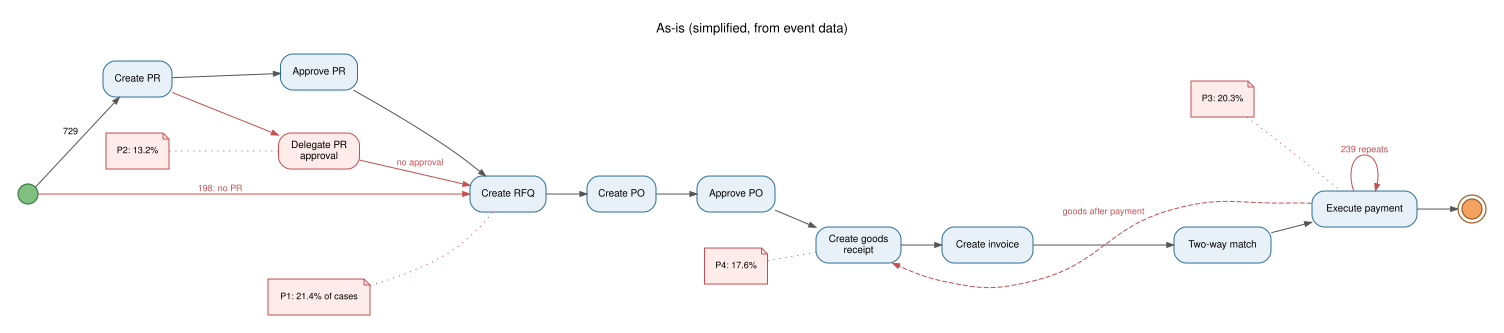

In [5]:
sys.path.insert(0, str(ROOT/'src')); import p2p_viz as v
def build_asis(rankdir):
    a = v.new_graph('asis', 'As-is (simplified, from event data)', rankdir, nodesep='0.5', ranksep='0.55')
    v.start(a, 's'); v.end(a, 'e')
    v.task(a,'cpr','Create PR'); v.task(a,'apr','Approve PR'); v.task(a,'dpr','Delegate PR\\napproval', 'issue')
    v.task(a,'rfq','Create RFQ'); v.task(a,'cpo','Create PO'); v.task(a,'apo','Approve PO'); v.task(a,'gr','Create goods\\nreceipt')
    v.task(a,'inv','Create invoice'); v.task(a,'m2','Two-way match'); v.task(a,'pay','Execute payment')
    red = dict(color=v.RED_LINE, fontcolor=v.RED_LINE)
    a.edge('s','cpr', label=f" {D['start_activities']['Create Purchase Requisition']} ")
    a.edge('s','rfq', label=f" {D['start_activities']['Create Request for Quotation']}: no PR ", **red)
    a.edge('cpr','apr'); a.edge('cpr','dpr', **red); a.edge('apr','rfq'); a.edge('dpr','rfq', label=' no approval ', **red)
    a.edge('rfq','cpo'); a.edge('cpo','apo'); a.edge('apo','gr'); a.edge('gr','inv'); a.edge('inv','m2'); a.edge('m2','pay')
    a.edge('pay','pay', label=f" {C['D1_extra_executions']} repeats ", **red)
    a.edge('pay','gr', label=' goods after payment ', style='dashed', constraint='false', **red)
    a.edge('pay','e')
    for k,(txt,tgt) in {'n1':(f"P1: {rule['A1']['cases_pct']}% of cases",'rfq'), 'n2':(f"P2: {rule['A2']['cases_pct']}%",'dpr'),
                        'n3':(f"P3: {rule['D1']['cases_pct']}%",'pay'), 'n4':(f"P4: {rule['C5']['cases_pct']}%",'gr')}.items():
        v.note(a,k,txt); a.edge(k, tgt, style='dotted', arrowhead='none', color=v.RED_LINE)
    return a
build_asis('LR').render(str(FIG/'05_asis_annotated'), format='png', cleanup=True)
build_asis('TB').render(str(FIG/'05_asis_annotated_tb'), format='png', cleanup=True)
build_asis('LR')

## 3. แผนภาพ to-be (BPMN-style แยกตามผู้รับผิดชอบ)
สีเขียว = control ใหม่ที่เสนอ ทุกจุดโยงกับปัญหา P1–P5

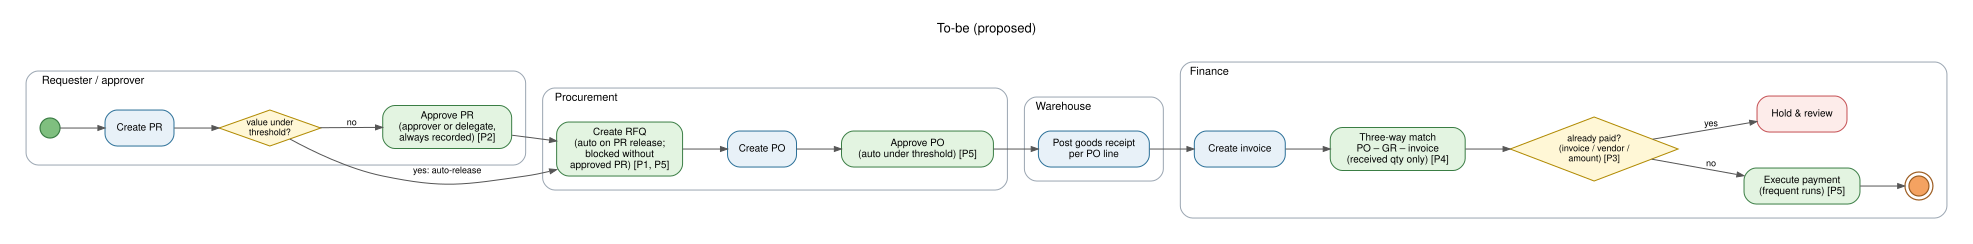

In [6]:
def build_tobe(rankdir):
    t = v.new_graph('tobe', 'To-be (proposed)', rankdir, nodesep='0.5', ranksep='0.6', compound='true', newrank='true')
    lane = dict(style='rounded', color='#9aa5b1', fontname=v.FONT, fontsize='11', labeljust='l', margin='14')
    with t.subgraph(name='cluster_req') as g:
        g.attr(label='Requester / approver', **lane)
        v.start(g,'s'); v.task(g,'cpr','Create PR')
        v.gateway(g,'g_auto','value under\\nthreshold?', margin='0.02')
        v.task(g,'apr','Approve PR\\n(approver or delegate,\\nalways recorded) [P2]', 'new')
    with t.subgraph(name='cluster_proc') as g:
        g.attr(label='Procurement', **lane)
        v.task(g,'rfq','Create RFQ\\n(auto on PR release;\\nblocked without\\napproved PR) [P1, P5]', 'new')
        v.task(g,'cpo','Create PO'); v.task(g,'apo','Approve PO\\n(auto under threshold) [P5]', 'new')
    with t.subgraph(name='cluster_wh') as g:
        g.attr(label='Warehouse', **lane)
        v.task(g,'gr','Post goods receipt\\nper PO line')
    with t.subgraph(name='cluster_fin') as g:
        g.attr(label='Finance', **lane)
        v.task(g,'inv','Create invoice')
        v.task(g,'m3','Three-way match\\nPO – GR – invoice\\n(received qty only) [P4]', 'new')
        v.gateway(g,'g_dup','already paid?\\n(invoice / vendor /\\namount) [P3]', margin='0.02')
        v.task(g,'pay','Execute payment\\n(frequent runs) [P5]', 'new'); v.task(g,'rev','Hold & review', 'issue'); v.end(g,'e')
    t.edge('s','cpr'); t.edge('cpr','g_auto')
    t.edge('g_auto','apr', label=' no '); t.edge('g_auto','rfq', label=' yes: auto-release ')
    t.edge('apr','rfq'); t.edge('rfq','cpo'); t.edge('cpo','apo'); t.edge('apo','gr'); t.edge('gr','inv'); t.edge('inv','m3')
    t.edge('m3','g_dup'); t.edge('g_dup','pay', label=' no '); t.edge('g_dup','rev', label=' yes '); t.edge('pay','e')
    return t
build_tobe('LR').render(str(FIG/'05_tobe'), format='png', cleanup=True)
build_tobe('TB').render(str(FIG/'05_tobe_tb'), format='png', cleanup=True)
build_tobe('LR')

## 4. สิ่งที่ข้อมูลตอบไม่ได้ (ต้องเขียนในข้อจำกัด)
- ข้อมูลเป็นข้อมูลจำลอง ทุกเคสจบที่การจ่ายเงิน ไม่มีเคสค้าง และกลุ่มต่างๆ (กลุ่มจัดซื้อ, วิธีจ่าย) แทบไม่ต่างกัน
- ไม่มียอดเงินของการจ่ายแต่ละครั้ง จึงยืนยันไม่ได้ว่าการจ่ายซ้ำเป็นการจ่ายเกิน
- ไม่มีวันที่ผู้ขายสัญญาส่งของที่เชื่อถือได้ จึงวัดการส่งของตรงเวลาไม่ได้
- log บอกได้ว่าอะไรเกิดขึ้น แต่ไม่บอกว่าทำไม สาเหตุทุกข้อต้องยืนยันกับเจ้าของกระบวนการ
- ข้อเสนอแนะยังไม่ได้นำไปใช้จริง จึงไม่มีตัวเลขผลลัพธ์

In [7]:
(ROOT/'results'/'05_recommendations.json').write_text(json.dumps(R, indent=2, ensure_ascii=False, default=str)); print('saved')

saved
